# Анализ лояльности пользователей Яндекс Афиши
- Автор: Андрей Творогов
- Дата: 22.02.2026

## Цели и задачи проекта
Цель проекта -  понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно.
Для достижения этой цели необходимо выпонить следующие задачи:
- Загрузка данных для анализа из СУБД.
- Предобработка данных с использованием возможностей библиотеки `pandas`.
- Построение профилей пользователей, содержащих агрегатные показатели заказов этих пользователей.
- Исследовательский анализ данных, включающий изучение взаимосвязи разных параметров профиля пользователя с количеством сделанных им заказов.

## Описание данных

Данные для анализа располагаются в схеме `afisha` базы данных `data-analyst-afisha` которая содержит пять таблиц.

#### Таблица `purchases`

Содержит информацию о заказах билетов:

- `order_id` — идентификатор заказа;
- `user_id` — идентификатор пользователя, совершившего заказ;
- `created_dt_msk` — дата создания заказа по московскому времени;
- `created_ts_msk` — дата и время создания заказа по московскому времени;
- `event_id` — идентификатор мероприятия из таблицы `events`;
- `cinema_circuit` — сеть кинотеатров, где проходит мероприятие. Если оно проходит не в кинотеатре, то здесь будет значение `нет`;
- `age_limit` — возрастное ограничение мероприятия;
- `currency_code` — валюта оплаты;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (например, `mobile` — мобильные устройства, `desktop` — компьютеры);
- `revenue` — выручка от заказа;
- `service_name` — название билетного оператора;
- `tickets_count` — количество купленных билетов;
- `total` — общая сумма заказа.

#### Таблица `events`

Содержит данные о мероприятиях, доступных на платформе:

- `event_id` — идентификатор мероприятия.
- `event_name_code` — название мероприятия в закодированном виде.
- `event_type_description` — описание мероприятия.
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее)
- `organizers` — организаторы мероприятия.
- `city_id` — идентификатор города проведения мероприятия из таблицы `cities`.
- `venue_id` — идентификатор площадки проведения мероприятия из таблицы `venues`.

#### Таблица `venues`

Содержит сведения о площадках проведения мероприятий:

- `venue_id` — идентификатор площадки;
- `venue_name` — название площадки;
- `address` — адрес площадки.

#### Таблица `city`

Содержит список городов, относящихся к регионам:

- `city_id` — идентификатор города;
- `city_name` — название города;
- `region_id` — идентификатор региона, в котором расположен город, из таблицы `regions`.

#### Таблица `regions`

Содержит список регионов, в которых проводятся мероприятия:

- `region_id` — идентификатор региона;
- `region_name` — название региона.

## Структура проекта
1. [Загрузка данных.](#1-загрузка-данных)
2. [Предобработка данных.](#2-предобработка-данных)
3. [Построение профилей пользователей.](#3-построение-профилей-пользователей)
4. [Исследовательский анализ данных.](#4-исследовательский-анализ-данных)<br>
    4.1 [Исследование признаков первого заказа.](#41-исследование-признаков-первого-заказа)<br>
    4.2 [Исследование поведения пользователей через показатели выручки и состава заказа.](#42-исследование-поведения-пользователей-через-показатели-выручки-и-состава-заказа)<br>
    4.3.[Исследование временных характеристик первого заказа и их влияния на повторные покупки.](#43-исследование-временных-характеристик-первого-заказа-и-их-влияния-на-повторные-покупки)<br>
    4.4.[Корреляционный анализ количества покупок и признаков пользователя.](#44-корреляционный-анализ-количества-покупок-и-признаков-пользователя)<br>
5. [Выводы](#5-выводы)

## 1. Загрузка данных

- Установка дополнительных библиотек:

In [ ]:
# Установка зависимостей через requirements.txt не работает из-за несоответствия версии jupyter_core
#%pip install -r requirements.txt

%pip install python-dotenv
%pip install phik
%pip install --upgrade seaborn
%pip install --upgrade sqlalchemy
%pip install --upgrade jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- Импорт необходимых библиотек:

In [2]:
# Библиотеки для загрузки параметров из файлов .env
import os
from dotenv import load_dotenv

import pandas as pd
import numpy as np

# Библиотека для доступа к СУБД
from sqlalchemy import create_engine

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Библиотека phik для анализа корреляций
import phik

- Установка параметров соединения с СУБД:

In [3]:
# Загрузка файла конфигурации
load_dotenv()

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv("DB_USER"),
    os.getenv("DB_PASSWORD"),
    os.getenv("DB_HOST"),
    os.getenv("DB_PORT"),
    os.getenv("DB_NAME")
)


- Создание соединения с СУБД, выполнение SQL-запроса и загрузка данных в датафрейм::

In [4]:
# Создание пула соединений
engine = create_engine(connection_string) 

query = '''
SELECT
	user_id,
	device_type_canonical,
	order_id,
	created_dt_msk AS order_dt,
	created_ts_msk AS order_ts,
	currency_code,
	revenue,
	tickets_count,
	EXTRACT (DAY FROM (created_dt_msk - LAG(created_dt_msk, 1, NULL) 
				OVER (PARTITION BY user_id ORDER BY created_dt_msk))) AS days_since_prev,
	event_id,
	event_name_code AS event_name,
	service_name,
	event_type_main,
	region_name,
	city_name
FROM
	afisha.purchases
	INNER JOIN afisha.events USING(event_id)
	INNER JOIN afisha.city USING(city_id)
	INNER JOIN afisha.regions USING (region_id)
WHERE
	device_type_canonical IN ('mobile', 'desktop')
	AND event_type_description <> 'фильм'
ORDER BY user_id
''' 

# Загрузка данных в датафрейм
df = pd.read_sql_query(query, con=engine) 

- Пример данных и количество строк:

In [5]:
initial_count = len(df)

print("Количество строк в датасете: ", initial_count)
display(df.head(5))

Количество строк в датасете:  290611


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


- Описание датасета:

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  service_name           290611 non-null  str           
 12  event_type_main        290611 non-null  str           


**Вывод:**
Пропуски присутствуют только в столбце `days_since_prev`, что соответствует условию задания. В соответствии с наличием пропусков тип поля - `float64`, а не `intXX`.

## 2. Предобработка данных

- Загрузка информации о курсах валют и добавление столбца `revenue_rub` с суммой в рублях:

In [7]:
# Загрузка датасета
df_curr_course = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv")

# Добавление столбца с типом datetime64 для соединения с основным датасетом
df_curr_course['date'] = pd.to_datetime(df_curr_course['data'], format='%Y-%m-%d')

# Соединение датасетов по дате
df_tmp = df.merge(df_curr_course, left_on='order_dt', right_on='date')

# Добавление столбца с суммой в рублях
df['revenue_rub'] = df_tmp.apply(lambda r: r['revenue'] if r['currency_code']=='rub' else r['revenue']*r['curs']/100.0,
                                 axis=1)
# Проверка
display(df[df['currency_code']=='kzt'][['revenue', 'revenue_rub']].head())

,revenue,revenue_rub
70,518.10,98.503762
89,347.18,65.731589
96,328.77,61.148261
277,22021.55,4380.702898
460,7397.66,1478.296591


- Определим, можно ли уменьшить размерность числовых типов:

In [8]:
display(df.describe().loc[['max', 'min']])

,order_id,order_dt,order_ts,revenue,tickets_count,days_since_prev,event_id,revenue_rub
max,8653108.0,2024-10-31 00:00:00,2024-10-31 23:59:54,81174.54,57.0,148.0,592325.0,81174.54
min,1.0,2024-06-01 00:00:00,2024-06-01 00:00:42,-90.76,1.0,0.0,4436.0,-90.76


- Можно уменьшить разрядность столбца `tickets_count` до 8, а столбцов `order_id` и `event_id` - до 32:

In [9]:
# Преобразование типов столбцов
df['order_id'] = df['order_id'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')
df['tickets_count'] = df['tickets_count'].astype('int8')

# Проверка
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  service_name           290611 non-null  str           
 12  event_type_main        290611 non-null  str           


- Проверка категориальных данных:

In [10]:
display(pd.DataFrame(df['event_type_main'].unique()))

,0
0,театр
1,выставки
2,другое
3,стендап
4,концерты
5,спорт
6,ёлки


Значение `'другое'` является заглушкой, это надо учитывать при дальнейшем анализе.

- Построим гистограмму распределения выручки `revenue_rub`:

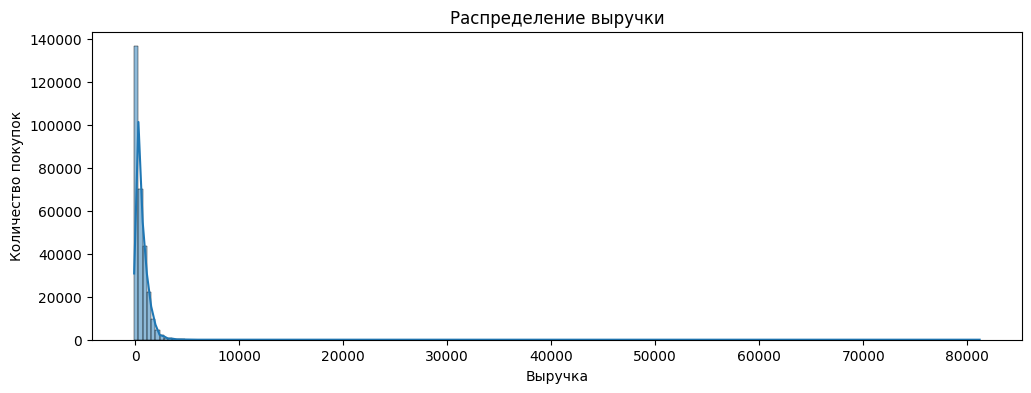

In [11]:
def draw_histogram(title,
                   xlabel, 
                   ylabel, 
                   figsize=(12, 4),
                   **kwargs):
    plt.figure(figsize=figsize)
    sns.histplot(**kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Гистограмма распределения выручки
draw_histogram("Распределение выручки",
               "Выручка",
               "Количество покупок",
               data=df,
               x='revenue_rub',
               bins=200,
               kde=True)


Значения выручки `revenue_rub` содержат выбросы. Отфильтруем записи по 99 процентилю в этом поле, а также удалим отрицательные значения:

Первоначальное количество строк: 290611.
Количество строк после удаления: 281879.
Удалено строк: 8732 (3.0%)


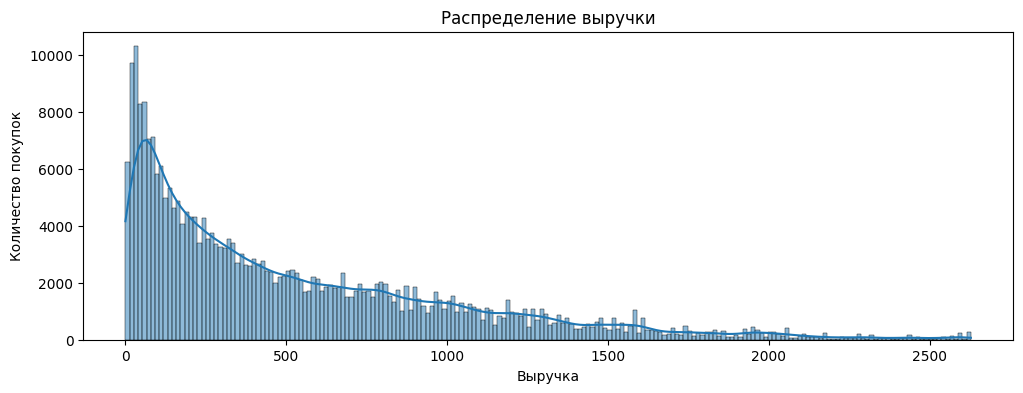

In [12]:
# Получаем 99 процентиль с положительным revenue_rub
percentile_99 = df['revenue_rub'].quantile(0.99)
df = df[(df['revenue_rub'] > 0.0) & (df['revenue_rub'] <= percentile_99)]

delta = initial_count - len(df)

print(f"Первоначальное количество строк: {initial_count}.")
print(f"Количество строк после удаления: {len(df)}.")
print(f"Удалено строк: {delta} ({round(delta/initial_count*100.0, 2)}%)")

# Гистограмма распределения выручки
draw_histogram("Распределение выручки",
               "Выручка",
               "Количество покупок",
               data=df,
               x='revenue_rub',
               bins=200,
               kde=True)

- Построим боксплот распределения количества билетов:

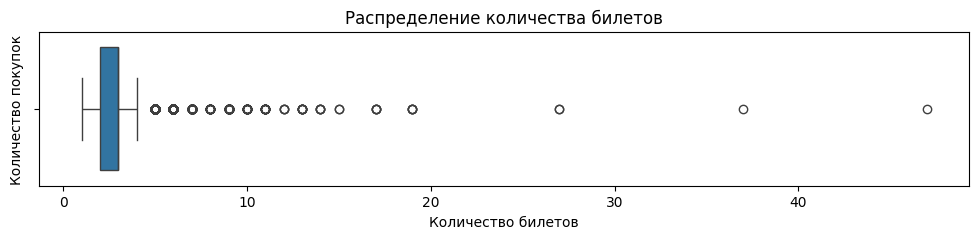

In [13]:
# Диаграмма распределения количества билетов
plt.figure(figsize=(12, 2))
sns.boxplot(data=df, x='tickets_count')

# plt.xticks(np.arange(0, 1300, step=50), rotation=90)
plt.title("Распределение количества билетов")
plt.xlabel("Количество билетов")
plt.ylabel("Количество покупок")
plt.show()

На диаграмме видны выбросы в количестве купленных билетов, но удалять их на данном этапе нецелесообразно, потому что это может исказить сведения о профилях пользователей.

## 3. Построение профилей пользователей

- Вычисляем параметры профиля:

In [14]:
# Группируем датасет по user_id
df_grouped = df.sort_values(by='order_dt').groupby('user_id')

# Вычисляем переиспользуемые параметры
first_orders = df_grouped.first()
last_orders = df_grouped.last()
orders_counts = df_grouped['order_id'].count()

# Формируем датафрейм с профилями пользователей
df_user_profile = pd.DataFrame({'first_order_dt': first_orders['order_dt'],
                                'last_order_dt': last_orders['order_dt'],
                                'first_order_device': first_orders['device_type_canonical'],
                                'first_order_region': first_orders['region_name'],
                                'first_order_service_name': first_orders['service_name'],
                                'first_order_genre': first_orders['event_type_main'],
                                'orders_count': orders_counts,
                                'avg_revenue_rub': df_grouped['revenue_rub'].mean(),
                                'avg_tickets_count': df_grouped['tickets_count'].mean(),
                                'avg_interval': ((last_orders['order_dt'] - first_orders['order_dt']) / orders_counts).dt.days})

# Дополнительные флаги
df_user_profile['is_two'] = df_user_profile['orders_count'] >= 2
df_user_profile['is_five'] = df_user_profile['orders_count'] >= 5

display(df_user_profile.info())
display(df_user_profile.head())

<class 'pandas.DataFrame'>
Index: 21700 entries, 0002849b70a3ce2 to ffff00725179321
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   first_order_dt            21700 non-null  datetime64[us]
 1   last_order_dt             21700 non-null  datetime64[us]
 2   first_order_device        21700 non-null  str           
 3   first_order_region        21700 non-null  str           
 4   first_order_service_name  21700 non-null  str           
 5   first_order_genre         21700 non-null  str           
 6   orders_count              21700 non-null  int64         
 7   avg_revenue_rub           21700 non-null  float64       
 8   avg_tickets_count         21700 non-null  float64       
 9   avg_interval              21700 non-null  int64         
 10  is_two                    21700 non-null  bool          
 11  is_five                   21700 non-null  bool          
dtypes: bool(2)

None

,first_order_dt,last_order_dt,first_order_device,first_order_region,first_order_service_name,first_order_genre,orders_count,avg_revenue_rub,avg_tickets_count,avg_interval,is_two,is_five
user_id,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,0,False,False
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,37,True,False
000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,34,True,False
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,0,False,False
000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,8,True,False


- Рассчитаем агрегатные показатели по профилям пользователей:

In [15]:
print("Число пользователей:", len(df_user_profile))
print(f"Средняя выручка с заказа: {df_user_profile['avg_revenue_rub'].mean():.2f}р.")
print(f"Доля пользователей с 2 и более заказами: {df_user_profile['is_two'].mean():.2f}")
print(f"Доля пользователей с 5 и более заказами: {df_user_profile['is_five'].mean():.2f}")

Число пользователей: 21700
Средняя выручка с заказа: 551.88р.
Доля пользователей с 2 и более заказами: 0.62
Доля пользователей с 5 и более заказами: 0.29


- Также рассчитаем статистические показатели по числовым параметрам:

In [16]:
# Статистические показатели
display(df_user_profile[['orders_count', 'avg_tickets_count', 'avg_interval']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

,orders_count,avg_tickets_count,avg_interval
count,21700.000000,21700.000000,21700.000000
mean,12.989816,2.746006,6.335115
std,119.766778,0.914290,10.866952
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,0.000000
50%,2.000000,2.750000,0.000000
75%,5.000000,3.090909,9.000000
90%,15.000000,4.000000,20.000000
95%,31.000000,4.000000,30.000000
99%,150.010000,5.000000,50.000000


В поле `orders_count` присутствуют выбросы - аномально большие значения. Их количество невелико - если отфильтровать данные по 99 процентилю, все они будут удалены.

In [17]:
users_count_before_filter = len(df_user_profile)

# Отфильтруем профили по 99 процентилю orders_count
percentile_99 = df_user_profile['orders_count'].quantile(0.99)
df_user_profile = df_user_profile[df_user_profile['orders_count'] <= percentile_99]
deleted_count = users_count_before_filter - len(df_user_profile)

print(f"Было удалено {deleted_count} строк ({deleted_count / users_count_before_filter * 100:.2f}%).")
print(f"Количество оставшихся пользователей: {len(df_user_profile)}")

Было удалено 217 строк (1.00%).
Количество оставшихся пользователей: 21483


- Обновленные статистические показатели:

In [18]:
# Статистические показатели
display(df_user_profile[['orders_count', 'avg_tickets_count', 'avg_interval']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

,orders_count,avg_tickets_count,avg_interval
count,21483.000000,21483.000000,21483.000000
mean,6.404506,2.746183,6.399106
std,13.982574,0.918756,10.902937
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,0.000000
50%,2.000000,2.750000,0.000000
75%,5.000000,3.111111,9.000000
90%,14.000000,4.000000,21.000000
95%,26.000000,4.000000,30.000000
99%,78.000000,5.000000,50.000000


## 4. Исследовательский анализ данных

На данном этапе стоит задача исследовать признаки, влияющие на возврат пользователей, то есть совершение ими повторного заказа.

### 4.1. Исследование признаков первого заказа

- Построим датасеты с сегментацией данных по признакам первого заказа и вычислением доли пользователей, сделавших более одного заказа: 

In [19]:
def segment_counts(col_name):
    rv_df = pd.DataFrame({"quantity": df_user_profile[col_name].value_counts(),
                          "ratio": df_user_profile[col_name].value_counts() / len(df_user_profile),
                          "return_ratio": df_user_profile.groupby(by=col_name)['is_two'].mean()})
    display(rv_df.sort_values(by="quantity", ascending=False).head(10).style.background_gradient(cmap='viridis'))
    return rv_df

# Количество и доля пользователей по типу мероприятия
df_genre_segments = segment_counts('first_order_genre')

# Количество и доля пользователей по типу устройства
df_device_segments = segment_counts('first_order_device')

# Количество и доля пользователей по региону
df_region_segments = segment_counts('first_order_region')

# Количество и доля пользователей по билетному оператору
df_service_segments = segment_counts('first_order_service_name')

,quantity,ratio,return_ratio
first_order_genre,,,
концерты,9613,0.447470,0.618017
другое,5224,0.243169,0.594372
театр,4253,0.197970,0.634376
стендап,1120,0.052134,0.609821
спорт,766,0.035656,0.549608
выставки,412,0.019178,0.640777
ёлки,95,0.004422,0.557895


,quantity,ratio,return_ratio
first_order_device,,,
mobile,17783,0.827771,0.607659
desktop,3700,0.172229,0.637568


,quantity,ratio,return_ratio
first_order_region,,,
Каменевский регион,6967,0.324303,0.618774
Североярская область,3793,0.176558,0.641445
Широковская область,1227,0.057115,0.643032
Озернинский край,681,0.031699,0.553598
Малиновоярский округ,523,0.024345,0.554493
Шанырский регион,464,0.021598,0.693966
Светополянский округ,461,0.021459,0.657267
Травяная область,460,0.021412,0.615217
Речиновская область,447,0.020807,0.639821


,quantity,ratio,return_ratio
first_order_service_name,,,
Билеты без проблем,4965,0.231113,0.597382
Мой билет,2987,0.139040,0.606629
Лови билет!,2801,0.130382,0.611210
Билеты в руки,2545,0.118466,0.629077
Облачко,2199,0.102360,0.613915
Весь в билетах,1291,0.060094,0.628970
Лучшие билеты,1192,0.055486,0.617450
Прачечная,579,0.026952,0.621762
Край билетов,461,0.021459,0.655098


Распределение пользователей по сегментам неравномерно - по каждому из признаков есть сегменты, являющиеся лидерами по количеству пользователей. 
- Больше всего пользователей впервые приобрели билет на концерты (44.7%) и в театр (19.8%). На втором месте находится категория `другое` (24.3%).
- 82.1% пользователей приобрели первый билет через мобильное устройство.
- Среди регионов лидерами являются Каменевский регион и Североярская область (32.4% и 17.6% соответственно)
- Среди билетных операторов лидируют 5 операторов с суммарной долей 49%

Построим столбчатые диаграммы доли возвращающихся пользователей по всем показателям и сегментам:

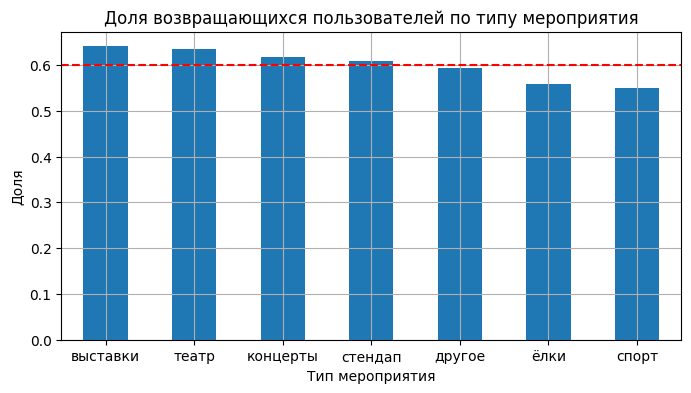

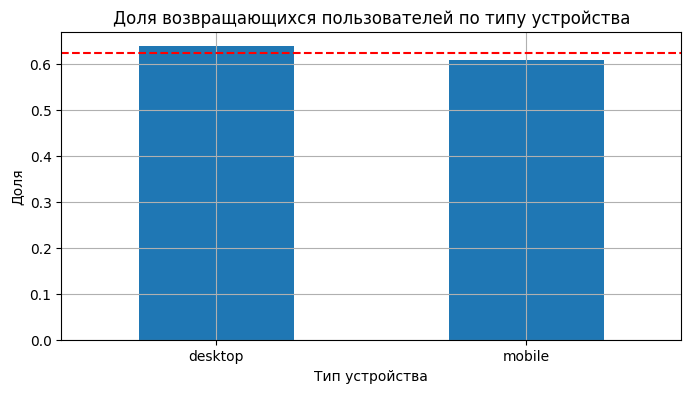

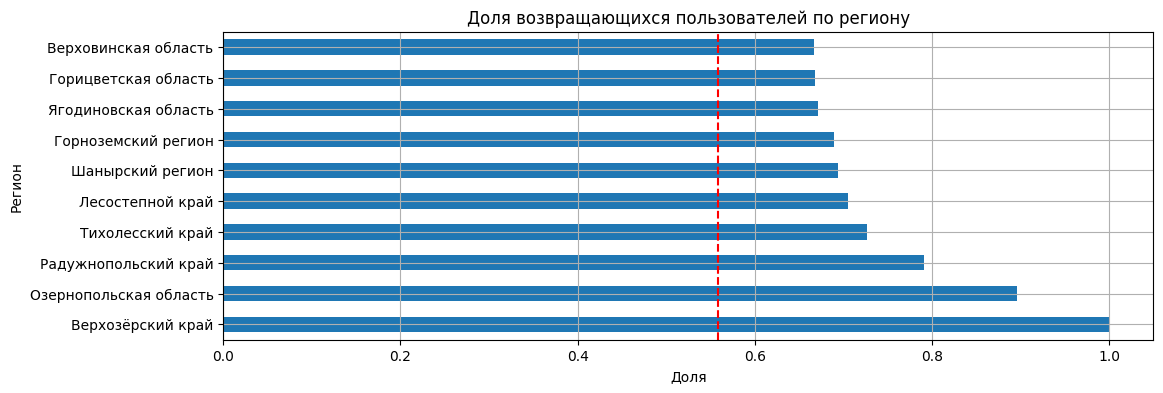

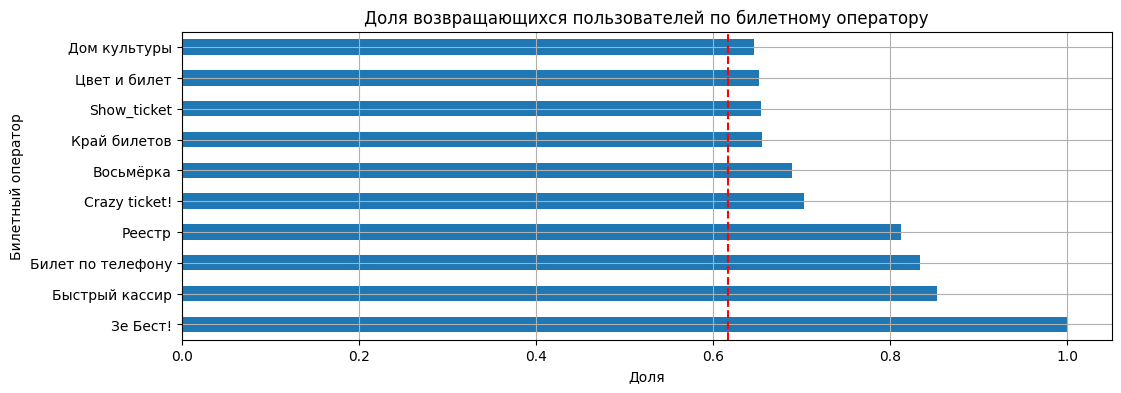

In [20]:
def draw_barplot(series, title, xlabel, ylabel, rot=0, vertical=True):
    series.sort_values(ascending=False).head(10).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if vertical:
        plt.axhline(series.mean(), color='red', linestyle='--')
    else:
        plt.axvline(series.mean(), color='red', linestyle='--')
    plt.show()

draw_barplot(df_genre_segments['return_ratio'], "Доля возвращающихся пользователей по типу мероприятия", "Тип мероприятия", "Доля")
draw_barplot(df_device_segments['return_ratio'], "Доля возвращающихся пользователей по типу устройства", "Тип устройства", "Доля")
draw_barplot(df_region_segments['return_ratio'], "Доля возвращающихся пользователей по региону", "Регион", "Доля", vertical=False)
draw_barplot(df_service_segments['return_ratio'], "Доля возвращающихся пользователей по билетному оператору", "Билетный оператор", "Доля", vertical=False)

- Более других делают повторный заказ пользователи, у которых первый тип мероприятия - **выставка, театр, концерт или стендап**. **Гипотеза о том, что чаще возвращаются пользователи с первым заказом на спортивные мероприятия, оказывается неверной**

Среди долей возвратов по регионам присутствуют подозрительные данные (доля возвращающихся пользователей около 1). Возможно, данные по ним нерелевантны из-за низкого количества клиентов. Сопоставим для них долю возвратов с количеством клиентов:

In [21]:
display(df_region_segments.sort_values(by="return_ratio", ascending=False).head(15).style.background_gradient(cmap='viridis'))

,quantity,ratio,return_ratio
first_order_region,,,
Верхозёрский край,1,0.000047,1.000000
Озернопольская область,29,0.001350,0.896552
Радужнопольский край,24,0.001117,0.791667
Тихолесский край,11,0.000512,0.727273
Лесостепной край,61,0.002839,0.704918
Шанырский регион,464,0.021598,0.693966
Горноземский регион,29,0.001350,0.689655
Ягодиновская область,64,0.002979,0.671875
Горицветская область,247,0.011497,0.668016


Видно, что регионы с наибольшей долей возвратов содержат не более 100 клиентов с первым заказом в этом регионе (десятые доли процента), поэтому эти сведения нерелевантны. Построим диаграмму доли возвратов, отбросив регионы с долей клиентов меньше 1% и добавив для сравнения долю пользователей с первым заказом в этом регионе:

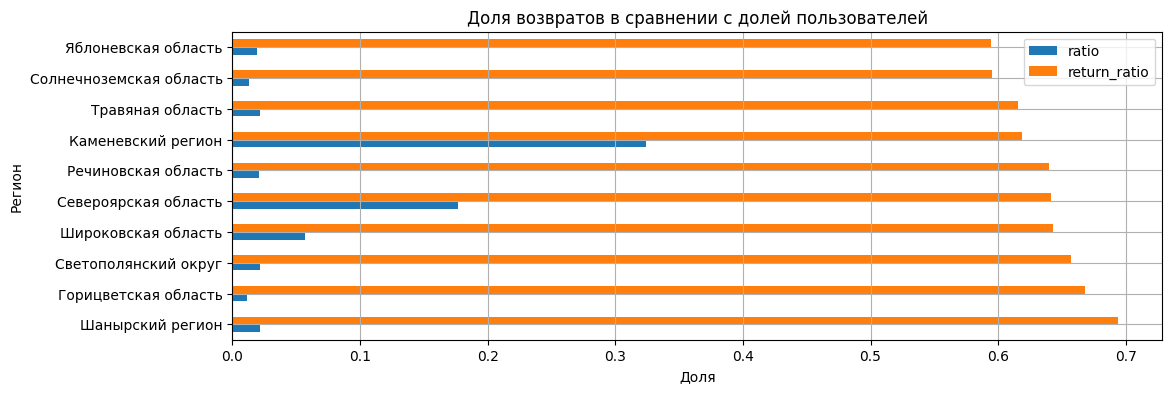

In [22]:
df_region_segments[df_region_segments['ratio'] >= 0.01][['ratio', 'return_ratio']].sort_values(by='return_ratio', ascending=False).head(10).plot(
    title="Доля возвратов в сравнении с долей пользователей",
    kind='barh',
    figsize=(12, 4),
    xlabel="Доля",
    ylabel="Регион",
    grid=True)
plt.show()

- Видно, что **нет прямой зависимости между количеством пользователей в регионе и количеством возвратов в нем**.

### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

- Исследуем соотношение средней выручки c долями вернувшихся и не вернувшихся пользователей:

In [23]:
# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, hue, xlabel, ylabel, stat='count', figsize=(12, 6)):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel('')  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=True,
                stat=stat)

    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)

    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

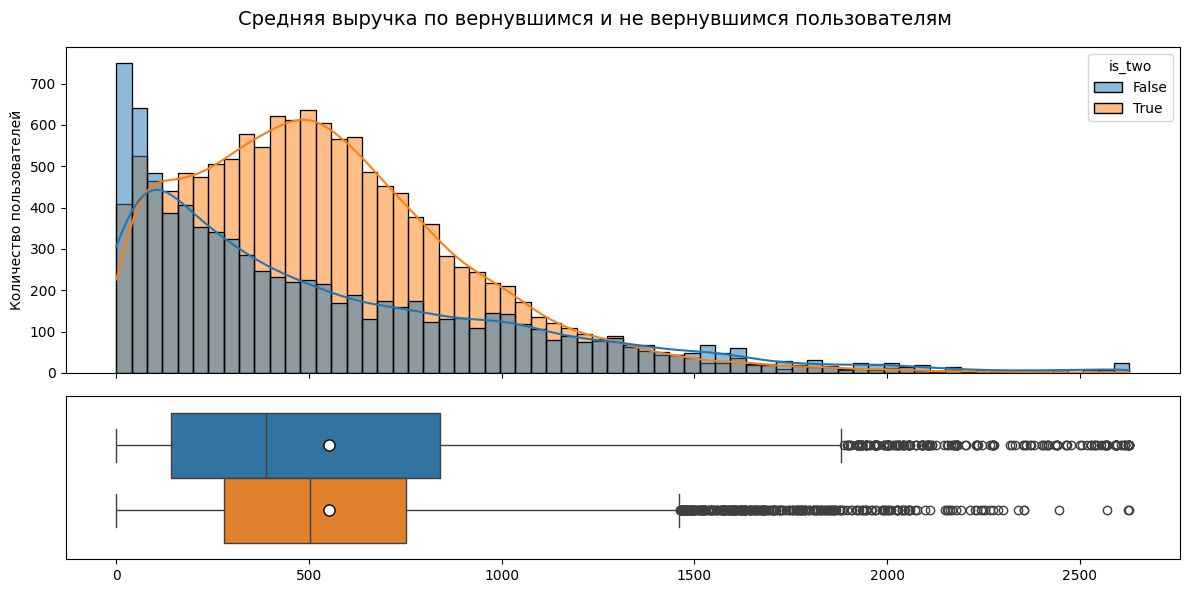

Статистика по вернувшимся пользователям:


count    13165.000000
mean       551.810878
std        369.147545
min          0.352000
25%        278.415000
50%        503.268000
75%        751.592298
max       2628.421739
Name: avg_revenue_rub, dtype: float64

Статистика по одноразовым пользователям:


count    8318.000000
mean      552.678607
std       519.044834
min         0.070000
25%       141.140000
50%       388.715000
75%       839.520000
max      2628.421739
Name: avg_revenue_rub, dtype: float64

In [24]:
draw_double_diag(df_user_profile,
                 'Средняя выручка по вернувшимся и не вернувшимся пользователям',
                 'avg_revenue_rub',
                 'is_two',
                 'Средняя выручка, р.',
                 'Количество пользователей')

print("Статистика по вернувшимся пользователям:")
display(df_user_profile[df_user_profile['is_two']]['avg_revenue_rub'].describe())
print("Статистика по одноразовым пользователям:")
display(df_user_profile[~(df_user_profile['is_two'])]['avg_revenue_rub'].describe())


- Оба распределения асимметричны, у распределения выручки среди вернувшихся клиентов правый хвост короче, пик смещен вправо.
- Максимальное количество вернувшихся клиентов совершает совершает покупки в среднем на 503 р., одноразовых - примерно на 100 р.
- Медианная выручка по одноразовым пользователям ниже, чем по вернувшимся, однако средние значения находятся на одном уровне.
- Выручка от одноразовых пользователей имеет больший межквартильный интервал и концентрируется в диапазоне 141-839 р.
- Выручка от вернувшихся пользователей сконцентрирована в диапазоне 278-751 р.

Исследуем подробнее статистику по возвращающимся пользователям в двух группах:
- совершившие 2–4 заказа;
- совершившие 5 и более заказов;

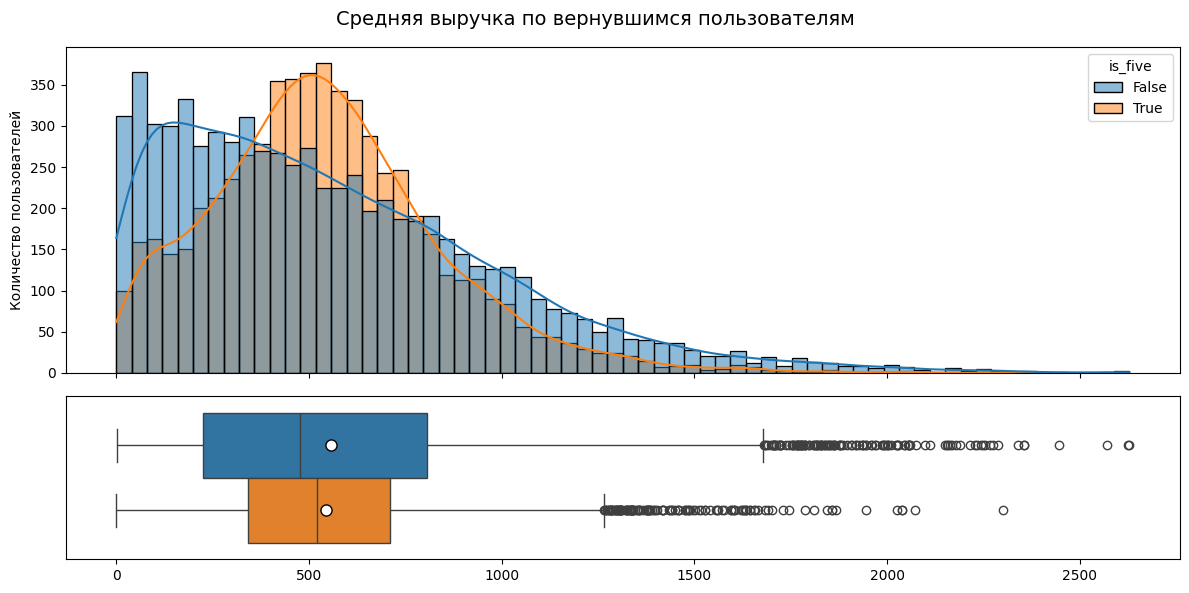

Статистика по пользователям с 5 и более заказами:


count    6047.000000
mean      544.909594
std       298.199286
min         0.352000
25%       341.254806
50%       521.755000
75%       710.633247
max      2299.869022
Name: avg_revenue_rub, dtype: float64

Статистика по пользователям с 2-4 заказами:


count    7118.000000
mean      557.673770
std       420.043202
min         2.416667
25%       224.187500
50%       477.645427
75%       806.266875
max      2628.421739
Name: avg_revenue_rub, dtype: float64

In [25]:
df_users_two = df_user_profile[df_user_profile['is_two']]

draw_double_diag(df_users_two,
                 'Средняя выручка по вернувшимся пользователям',
                 'avg_revenue_rub',
                 'is_five',
                 'Средняя выручка, р.',
                 'Количество пользователей')

print("Статистика по пользователям с 5 и более заказами:")
display(df_users_two[df_users_two['is_five']]['avg_revenue_rub'].describe())
print("Статистика по пользователям с 2-4 заказами:")
display(df_users_two[~(df_users_two['is_five'])]['avg_revenue_rub'].describe())

- Медиана выручки от пользователей, сделавших 2-4 заказа меньше, чем медиана выручки от пользователей с 5 и более заказами (477 против 521 р.)
- Среднее значение выручки наоборот, чуть больше у пользователей с 2-4 заказами (557 против 544 р.)
<br><br>
- Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.
Разделим пользователей на категории по среднему количеству билетов в заказе:

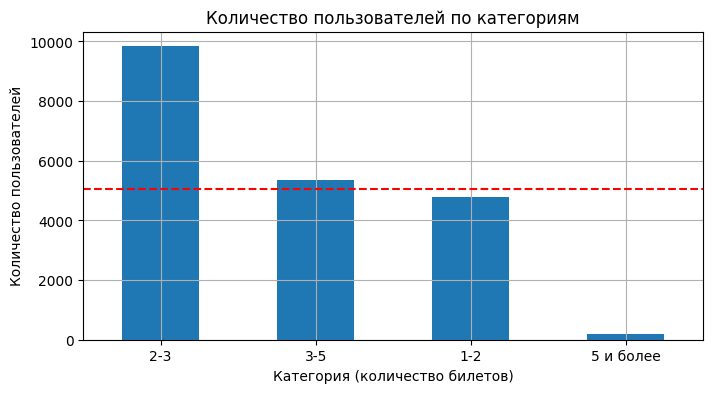

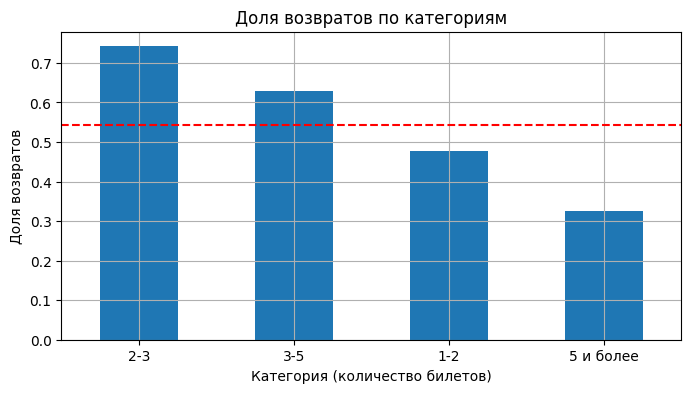

,Количество,Доля вернувшихся
avg_tickets_count,,
2-3,9833,0.742195
3-5,5347,0.628203
1-2,4783,0.477943
5 и более,194,0.324742


In [26]:
df_tc_cat = pd.cut(df_user_profile['avg_tickets_count'], 
                   bins=[1, 2, 3, 5, np.inf], 
                   labels=["1-2", "2-3", "3-5", "5 и более"]).value_counts()
df_tc_ret_cat = pd.cut(df_user_profile[df_user_profile['is_two']]['avg_tickets_count'], 
                       bins=[1, 2, 3, 5, np.inf], 
                       labels=["1-2", "2-3", "3-5", "5 и более"]).value_counts() / df_tc_cat

draw_barplot(df_tc_cat.sort_values(ascending=False),
              "Количество пользователей по категориям",
              "Категория (количество билетов)",
              "Количество пользователей")

draw_barplot(df_tc_ret_cat.sort_values(ascending=False),
             "Доля возвратов по категориям",
             "Категория (количество билетов)",
             "Доля возвратов")

display(pd.DataFrame({"Количество": df_tc_cat,
                      "Доля вернувшихся": df_tc_ret_cat}).style.background_gradient(cmap='viridis'))

- Пользователи распределены по категориям неравномерно: больше всего пользователей приобрели в среднем от 2 до 3 билетов, меньше всего - 5 и более.
- Доля возвращающихся пользователей в категории растет вместе с общим количеством пользователей в ней, но зависимость доли возвратов от количества пользователей нелинейная.

### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки
Исследуем влияние следующих параметров на вероятность возврата пользователей:
- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

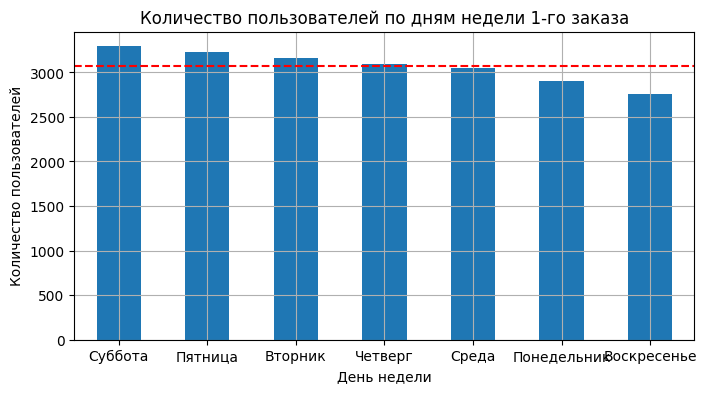

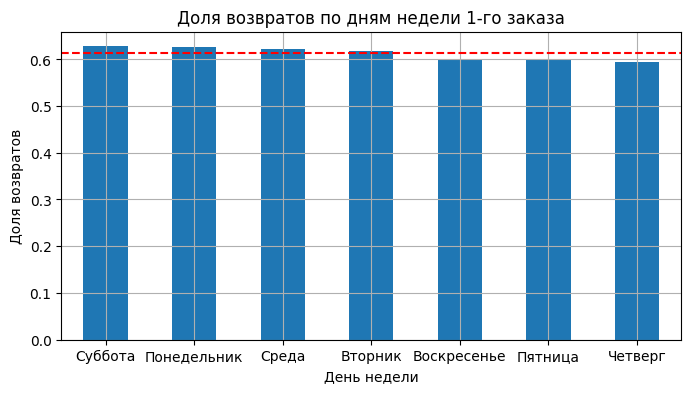

,Количество,Доля вернувшихся
first_order_dt,,
Суббота,3292,0.627886
Пятница,3230,0.599071
Вторник,3157,0.617358
Четверг,3098,0.594900
Среда,3048,0.621719
Понедельник,2901,0.626336
Воскресенье,2757,0.601741


In [27]:
df_1day_cat = df_user_profile['first_order_dt'].dt.day_of_week.value_counts().sort_values(ascending=False)
df_1day_ret_cat = (df_user_profile[df_user_profile['is_two']]['first_order_dt'].dt.day_of_week.value_counts() / df_1day_cat).sort_values(ascending=False)
days = {
    0: "Понедельник",
    1: "Вторник",
    2: "Среда",
    3: "Четверг",
    4: "Пятница",
    5: "Суббота",
    6: "Воскресенье"
}

df_1day_cat.index = df_1day_cat.index.map(days)
df_1day_ret_cat.index = df_1day_ret_cat.index.map(days)

draw_barplot(df_1day_cat.sort_values(ascending=False), 
             "Количество пользователей по дням недели 1-го заказа", 
             "День недели", 
             "Количество пользователей")

draw_barplot(df_1day_ret_cat.sort_values(ascending=False),
             "Доля возвратов по дням недели 1-го заказа",
             "День недели",
             "Доля возвратов",)

display(pd.DataFrame({"Количество": df_1day_cat,
                      "Доля вернувшихся": df_1day_ret_cat})
                      .sort_values(by="Количество", ascending=False)
                      .style
                      .background_gradient(cmap='viridis'))

- Наиболее часто первый заказ совершается накануне и в первый день выходных - с четверга по субботу, а также - во вторник, который является днем скидок в некоторых сетях кинотеатров.
- Чаще всего возвращаются пользователи, сделавшие первый заказ в субботу и понедельник, однако доля вернувшихся пользователей в зависимости от дня первой покупки различается незначительно, и вполне вероятно, что отличия являются случайными.

Исследуем зависимость возвратов от среднего интервала между заказами, а также от времени жизни (интервалом между датами последнего и первого заказа) в категориях пользователей `"2-4 заказа"` и `"5 и более заказов"`:

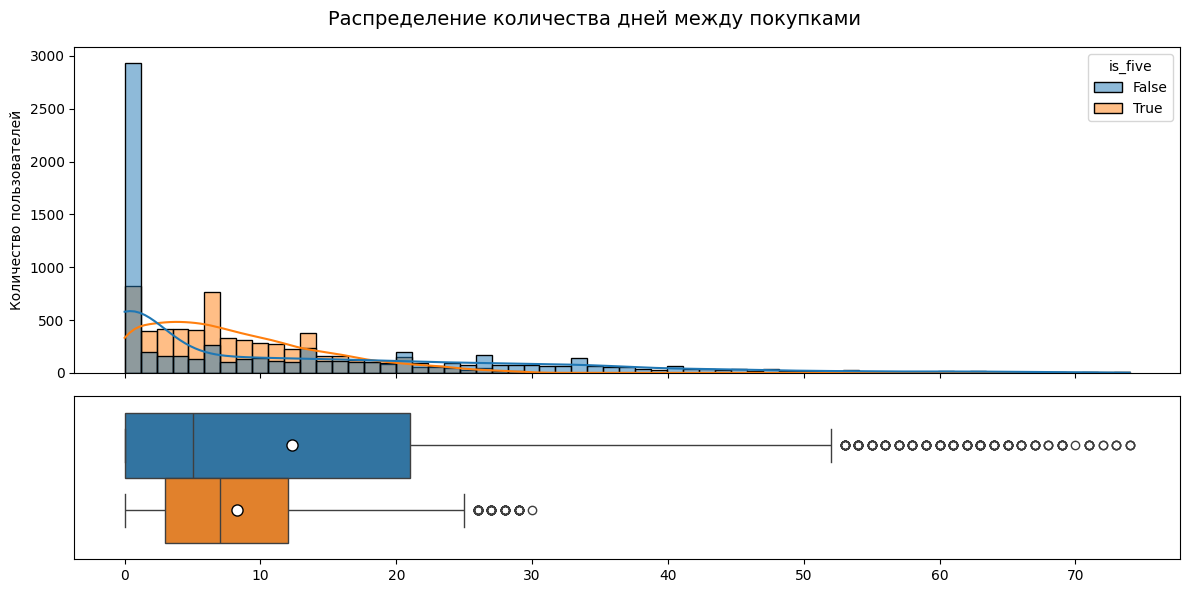

Статистика по пользователям с 2-4 заказами:


count    7118.000000
mean       12.299241
std        15.449177
min         0.000000
25%         0.000000
50%         5.000000
75%        21.000000
max        74.000000
Name: avg_interval, dtype: float64

Статистика по пользователям с 5 и более заказами:


count    6047.000000
mean        8.256325
std         6.375227
min         0.000000
25%         3.000000
50%         7.000000
75%        12.000000
max        30.000000
Name: avg_interval, dtype: float64

In [28]:
df_returned = df_user_profile[df_user_profile['is_two']]

draw_double_diag(df_returned,
                 "Распределение количества дней между покупками",
                 'avg_interval',
                 'is_five',
                 "Количество дней",
                 "Количество пользователей")

print("Статистика по пользователям с 2-4 заказами:")
display(df_returned[~(df_returned['is_five'])]['avg_interval'].describe())
print("Статистика по пользователям с 5 и более заказами:")
display(df_returned[df_returned['is_five']]['avg_interval'].describe())

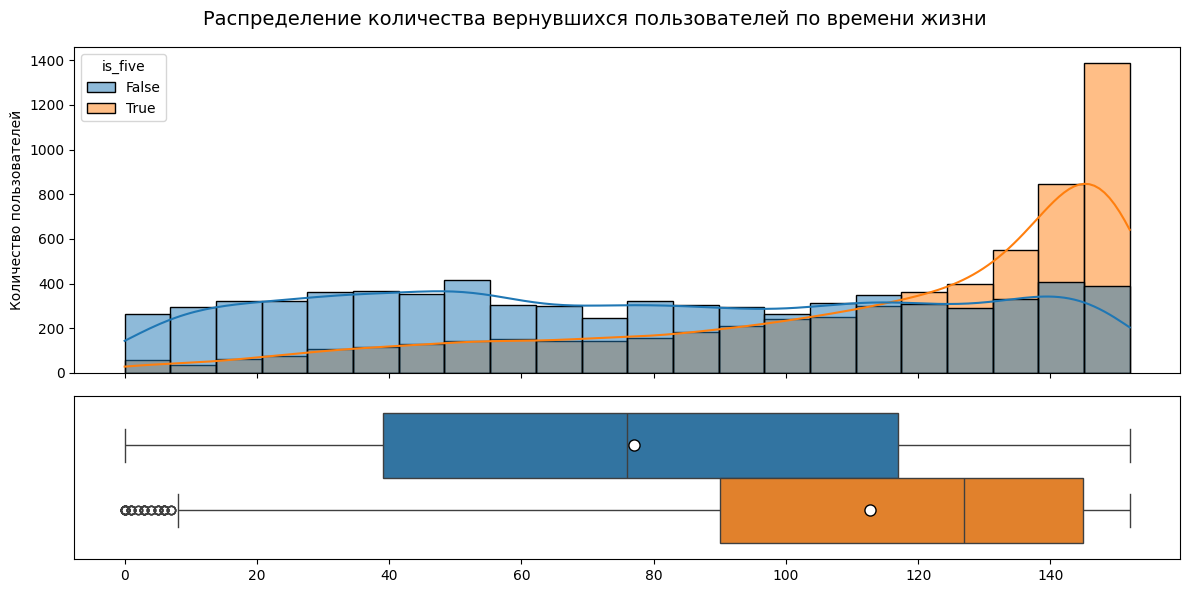

In [29]:
df_returned['lifetime'] = (df_returned['last_order_dt'].max() - df_returned['first_order_dt']).dt.days

draw_double_diag(df_returned,
                 "Распределение количества вернувшихся пользователей по времени жизни",
                 'lifetime',
                 'is_five',
                 "Дата",
                 "Количество пользователей")

- Наибольшее количество пользователе с 2-4 заказами совершают свои заказы в течение одного дня, однако присутствуют в небольшом количестве и выбросы до 74 дней, из-за чего среднее (12.3 дня) сильно отличается от медианы (5 дней). 
- У пользователей с 5 и более заказами распределение имеет другой характер - оно сконцентрировано в диапазоне 3-12 дней, максимальные выбросы не превышают 30 дней, среднее (8.2 дня) близко к медиане (7 дней).
- Распределение по времени, прошедшему с даты первого заказа, пользователей с 2-4 заказами близко к равномерному, а пользователей с 5 и более заказами монотонно возрастает, причем резкий рост начинается после 120 дней. Это согласуется с предыдущим распределением, так как большинство пользователей с 2-4 заказами делают их в один день, а у постоянных пользователей интервал между заказами больше и, соответственно, для размещения 5 и более заказов требуется больше времени.

**Вывод:**<br>
Совершение двух и более заказов в течение одного дня совсем не говорит о том, что пользователь еще вернется. Если интервал между заказами от 3 до 12 дней, велика вероятность, что такой пользователь станет постоянным (сделает 5 и более заказов). Но при увеличении интервала более 25-30 дней такой пользователь, скорее всего, не станет постоянным и не сделает более 2-4 заказов.

### 4.4. Корреляционный анализ количества покупок и признаков пользователя.
Исследуем связь характеристик профиля клиента, включая параметры первого заказа, с количеством заказов, чтобы определить признаки, которые в наибольшей степени влияют на лояльность.

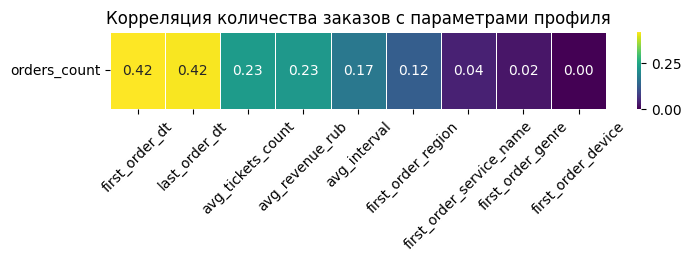

In [30]:
def draw_heatmap(df, title):
    plt.figure(figsize=(8,1))
    plt.title(title)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()    
    
# Вычислим матрицу корреляций
corr_columns = ['avg_revenue_rub', 
                'avg_tickets_count', 
                'avg_interval', 
                'first_order_dt', 
                'last_order_dt', 
                'first_order_region', 
                'first_order_device', 
                'first_order_service_name', 
                'first_order_genre']

interval_cols=['avg_revenue_rub', 
                'avg_tickets_count', 
                'avg_interval']

df_corr = phik.phik_matrix(df_user_profile[corr_columns + ['orders_count']],
                           interval_cols=interval_cols + ['orders_count'])[['orders_count']].sort_values(by='orders_count', ascending=False).drop('orders_count').T

# Построим тепловую карту корреляций
draw_heatmap(df_corr, "Корреляция количества заказов с параметрами профиля")

Корреляция с первой и последней датами заказа совпадает, потому что большинство пользователей сделали только один заказ или сделали все заказы в один день. Чтобы получить более точные данные, разобьем пользователей на категории по количеству заказов:

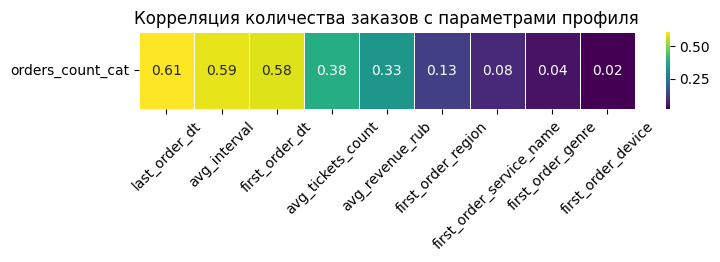

In [31]:
df_user_profile['orders_count_cat'] = pd.cut(df_user_profile['orders_count'], bins=[0, 1, 4, np.inf], labels=["1", "2-4", "5+"])

# Вычислим матрицу корреляций
df_corr = phik.phik_matrix(df_user_profile[corr_columns + ['orders_count_cat']],
                           interval_cols=interval_cols)[['orders_count_cat']].sort_values(by='orders_count_cat', ascending=False).drop('orders_count_cat').T

# Построим тепловую карту корреляций
draw_heatmap(df_corr, "Корреляция количества заказов с параметрами профиля")

Наибольшая корреляция количества заказов по категориям - с датами заказа и средним интервалом между заказами. Эти параметры взаимосвязаны, поэтому значения корреляции по ним близки друг к другу. В самом деле, на основании предшествующего анализа видно, что средний интервал между заказами в наибольшей степени характеризует постоянных пользователей. Следующие по значению корреляции параметры - среднее количество приобретенных билетов и средняя выручка по заказу. Наконец, наименьшее значение корреляции, указывающее не ее практическое отсутствие - у региона первого заказа, билетного оператора (эти параметры также взаимосвязаны), типа мероприятия и типа устройства.

## 5. Выводы
- Для анализа были представлены данные в виде записей в связанных таблицах базы данных PostgreSQL. 
- На первом этапе данные были загружены при помощи SQL-запроса в датафрейм. В процессе предобработки была сокращена разрядность некоторых целочисленных столбцов, удалены выбросы и некорректные отрицательные значения выручки.
- Для анализа параметров, влияющих на совершение пользователями повторных заказов, был построен датафрейм с профилями пользователей, включающие агрегатные параметры по заказам этих пользователей.
- Были построены диаграммы доли возвращающихся пользователей по категориальным признакам - типу мероприятия, типу устройства, региону, билетному оператору. Оказалось, что типы мероприятий, по которым количество возвратов выше среднего - выставки, театры, концерты, стендап. Чаще возвращаются пользователи, сделавшие первый заказ со стационарных устройств, однако разница в данном случае слишком мала, чтобы утверждать о существовании зависимости. Установлено, что данные по региону и билетному оператору не являются релевантными, потому что наибольшая доля возвращающихся пользователей набюдается в регионах с очень низким количеством покупок, а явной прямой зависимости доли возвратов от доли пользователей не прослеживается.
- Затем было проанализировано распределение выручки отдельно для вернувшихся и не вернувшихся пользователей, а также - для пользователей, сделавших 2-4 и 5 или более заказов. Оказалось, что максимальное количество вернувшихся клиентов совершает совершает покупки в среднем на 503 р., не вернувшихся - примерно на 100 р. Медианная выручка по не вернувшимся пользователям ниже, чем по вернувшимся, однако средние значения находятся на одном уровне. Выручка от не вернувшихся пользователей имеет больший межквартильный интервал и концентрируется в диапазоне 141-839 р. Выручка от вернувшихся пользователей сконцентрирована в диапазоне 278-751 р. Медиана выручки от пользователей, сделавших 2-4 заказа меньше, чем медиана выручки от пользователей с 5 и более заказами (477 против 521 р.), а среднее значение выручки наоборот, чуть больше у пользователей с 2-4 заказами (557 против 544 р.)
- В результате анализа зависимости количества заказов от среднего количества билетов в заказе выяснено, что доля возвратов выше средней среди пользователей, приобретших в среднем 2-3 и 3-5 билетов. Однако доля возвратов в данном случае прямо зависит от доли пользователей в соответствующей категории.
- Установлена зависимость количества первых заказов от дня недели - наибольшее количество заказов сделано в дни, предшествующие выходным, и во вторник. Доля возвратов в зависимости от дня недели первого заказа различается незначительно.
- На основании анализа зависимости количества заказов от среднего интервала между ними и от времени жизни (времени, прошедшего с первого заказа) было установлено, что если интервал между заказами от 3 до 12 дней, велика вероятность, что такой пользователь станет постоянным (сделает 5 и более заказов). Но при увеличении интервала более 25-30 дней такой пользователь, скорее всего, не станет постоянным и не сделает более 2-4 заказов.
- Корреляционный анализ показал, что наибольшая корреляция количества заказов по категориям - с датами заказа и средним интервалом между заказами. Следующие по значению корреляции параметры - среднее количество приобретенных билетов и средняя выручка по заказу.

Наиболее важный параметр, по которому можно отличить постоянных пользователей, - средний интервал между заказами. Имеет смысл привлекать рекламой и акциями пользователей, у которых с даты последнего заказа прошло от 12 до 25 дней, и таким образом стимулировать их к повторному возвращению. 

Успешными "точками входа" для постоянных клиентов являются выставки, театры, концерты и стендап. В то же время спортивные мероприятия показывают долю возвратов ниже средней, поэтому стоит обратить внимание на этот сегмент клиентов и стимулировать повторные покупки акциями и скидками.